<a href="https://colab.research.google.com/github/M4rcuSilv4/LAED/blob/main/Lista02_AV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random

class No:
    def __init__(self, dado):
        self.dado = dado
        self.proximo = None
        self.anterior = None

def criar_lista_dupla(t, limite_inferior, limite_superior):
    if t <= 0:
        return None
    inicio_lista = No(random.randint(limite_inferior, limite_superior))
    corrente = inicio_lista
    for _ in range(t - 1):
        novo_no = No(random.randint(limite_inferior, limite_superior))
        corrente.proximo = novo_no
        novo_no.anterior = corrente
        corrente = novo_no
    return inicio_lista

def exibir_dupla(lista_ref):
    corrente = lista_ref
    valores_lista = []
    while corrente:
        valores_lista.append(str(corrente.dado))
        corrente = corrente.proximo
    print("None <-> " + " <-> ".join(valores_lista) + " <-> None")

#1. O elemento central.
___

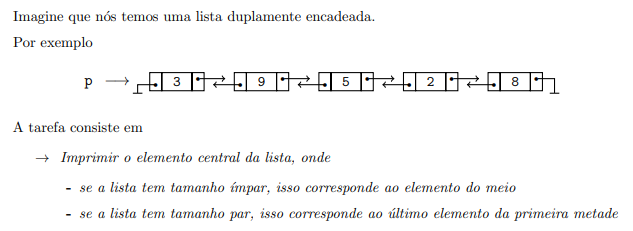

**a) Apresente um algoritmo que resolve esse problema.**

In [ ]:
def elemento_central(lista_ref):
    if lista_ref is None:
        return None

    lento = lista_ref
    rapido = lista_ref

    while rapido.proximo is not None and rapido.proximo.proximo is not None:
        lento = lento.proximo
        rapido = rapido.proximo.proximo

    print(f"O elemento central é o {lento.dado}.")
    return lento.dado

lista_exemplo = criar_lista_dupla(10, 1, 100)
exibir_dupla(lista_exemplo)

resultado = elemento_central(lista_exemplo)

None <-> 74 <-> 72 <-> 77 <-> 28 <-> 10 <-> 16 <-> 86 <-> 14 <-> 18 <-> 56 <-> None
O elemento central é o 10.


**b) Analise o tempo de execução do seu algoritmo.**

Tempo de execução O(N), linear, onde n é o número total de nós da lista, pois utiliza a técnica de dois ponteiros (lento e rápido) onde o ponteiro rápido percorre a lista em n/2 iterações, realizando apenas operações de avanço em tempo constante O(1).

# 2. Operação de atualização.
___

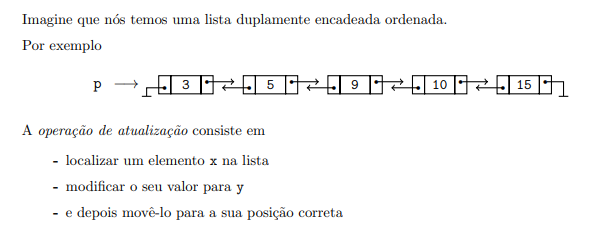

**a) Apresente um algoritmo que resolve esse problema.**

In [ ]:
def ordenar_dupla(lista_ref):
    if lista_ref is None:
        return None

    houve_troca = True
    while houve_troca:
        houve_troca = False
        no_atual = lista_ref
        while no_atual.proximo is not None:
            if no_atual.dado > no_atual.proximo.dado:
                no_atual.dado, no_atual.proximo.dado = no_atual.proximo.dado, no_atual.dado
                houve_troca = True
            no_atual = no_atual.proximo
    return lista_ref

def atualizar(lista_ref, valor_busca, valor_novo):
    no_atual = lista_ref
    while no_atual is not None and no_atual.dado != valor_busca:
        no_atual = no_atual.proximo

    if no_atual is None:
        print("Valor não encontrado na lista.")
        return lista_ref

    no_atual.dado = valor_novo

    while no_atual.anterior is not None and no_atual.dado < no_atual.anterior.dado:
        temporario = no_atual.dado
        no_atual.dado = no_atual.anterior.dado
        no_atual.anterior.dado = temporario
        no_atual = no_atual.anterior

    while no_atual.proximo is not None and no_atual.dado > no_atual.proximo.dado:
        temporario = no_atual.dado
        no_atual.dado = no_atual.proximo.dado
        no_atual.proximo.dado = temporario
        no_atual = no_atual.proximo

    return lista_ref

lista_ordenada = criar_lista_dupla(10, 1, 100)
lista_ordenada = ordenar_dupla(lista_ordenada)
print("A lista original é:")
exibir_dupla(lista_ordenada)

while True:
    valor_busca = int(input("\nDigite o valor que busca substituir na lista (entre 1 e 100): "))
    if valor_busca < 1 or valor_busca > 100:
        print("Valor fora do intervalo.")
    else:
        break

encontrado_valor = False
corrente_busca = lista_ordenada
while corrente_busca is not None:
    if corrente_busca.dado == valor_busca:
        encontrado_valor = True
        break
    corrente_busca = corrente_busca.proximo

if not encontrado_valor:
    print("Elemento não encontrado na lista.")
else:
    valor_novo = int(input("\nDigite o novo valor substituto: "))
    resultado = atualizar(lista_ordenada, valor_busca, valor_novo)
    exibir_dupla(resultado)


A lista original é:
None <-> 14 <-> 45 <-> 45 <-> 52 <-> 57 <-> 64 <-> 92 <-> 97 <-> 99 <-> 100 <-> None

Digite o valor que busca substituir na lista (entre 1 e 100): 20
Elemento não encontrado na lista.


**b) Analise o tempo de execução do seu algoritmo.**

A função "ordenar_dupla" possui complexidade de tempo O(N²) por utilizar O Bubble Sort na lista encadeada. A função principal "atualizar" possui tempo de execução O(N) (linear), pois a busca pelo valor *x* percorre no máximo os N nós da lista e o reposicionamento local do novo valor *y* realiza apenas trocas sequenciais de valores com os nós adjacentes em tempo constante O(1) por passo. Por fim, como o tempo de execução da busca se sobressai sobre o algoritmo, a complexidade do código é quadrática.

# 3. Varredura e ordenação.
___

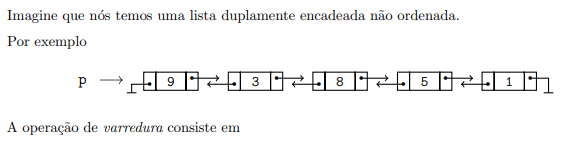
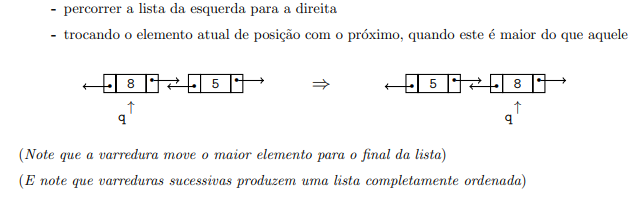

**a) Apresente um algoritmo que resolve esse problema.**

***Nota:*** Você deve trocar os elementos de lugar na lista (quando necessário), e não apenas trocar os números armazenados neles.

***Dica:*** Implemente a operação de troca como uma função em separado.

In [ ]:
def trocar_nos(lista_ref, no_a, no_b):
    anterior_no = no_a.anterior
    proximo_no = no_b.proximo

    if anterior_no is not None:
        anterior_no.proximo = no_b
    else:
        lista_ref = no_b

    if proximo_no is not None:
        proximo_no.anterior = no_a

    no_b.anterior = anterior_no
    no_b.proximo = no_a
    no_a.anterior = no_b
    no_a.proximo = proximo_no

    return lista_ref

def varredura(lista_ref):
    esquerda = lista_ref
    while esquerda is not None and esquerda.proximo is not None:
        if esquerda.dado > esquerda.proximo.dado:
            lista_ref = trocar_nos(lista_ref, esquerda, esquerda.proximo)
        else:
            esquerda = esquerda.proximo
    return lista_ref

lista_teste = criar_lista_dupla(10, 1, 100)
print("A lista é:")
exibir_dupla(lista_teste)

resultado = varredura(lista_teste)
print("\nA lista ordenada é:")
exibir_dupla(resultado)

#Estritamente como a questão pede, no caso de realizar múltiplas varreduras seria o mesmo que um Bubble_sort, já feito na questão anterior.

A lista é:
None <-> 98 <-> 92 <-> 36 <-> 26 <-> 49 <-> 20 <-> 35 <-> 58 <-> 53 <-> 71 <-> None

A lista ordenada é:
None <-> 92 <-> 36 <-> 26 <-> 49 <-> 20 <-> 35 <-> 58 <-> 53 <-> 71 <-> 98 <-> None


**b) Analise o tempo de execução do seu algoritmo.**

O algoritmo de varredura possui tempo de execução O(N), linear, onde N é o número de nós da lista, pois realiza uma única passagem da esquerda para a direita percorrendo os N nós e efetuando trocas físicas de nós através da atualização de ponteiros em tempo constante O(1) por nó.

# 4. Partição.
___

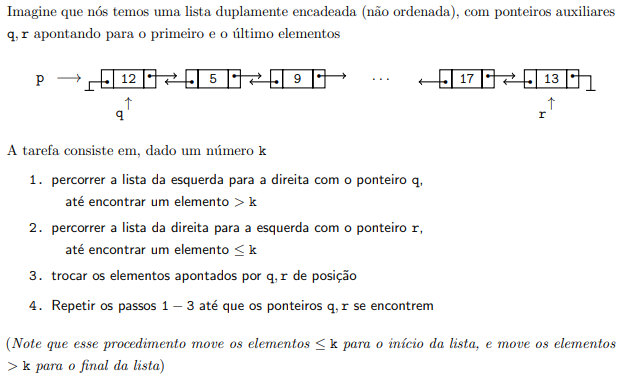

**a) Apresente um algoritmo que resolve esse problema.**

In [ ]:
def criar_lista_dupla2(t, limite_inferior, limite_superior):
    if t <= 0:
        return None, None
    inicio_lista = No(random.randint(limite_inferior, limite_superior))
    corrente = inicio_lista
    for _ in range(t - 1):
        novo_no = No(random.randint(limite_inferior, limite_superior))
        corrente.proximo = novo_no
        novo_no.anterior = corrente
        corrente = novo_no
    return inicio_lista, corrente

def particionar_qr(esquerda, direita, pivo):
    while esquerda is not None and direita is not None and esquerda != direita and esquerda.anterior != direita:
        while esquerda is not None and esquerda != direita and esquerda.dado <= pivo:
            esquerda = esquerda.proximo

        while direita is not None and direita != esquerda and direita.dado > pivo:
            direita = direita.anterior

        if esquerda is not None and direita is not None and esquerda != direita and esquerda.anterior != direita:
            if esquerda.dado > pivo and direita.dado <= pivo:
                esquerda.dado, direita.dado = direita.dado, esquerda.dado

inicio_particao, fim_particao = criar_lista_dupla2(10, 1, 100)
cursor_particao = inicio_particao
print("Alista original é:")
exibir_dupla(inicio_particao)

while True:
    pivo = int(input("\nDigite um número o valor de partição: "))
    if pivo < 1 or pivo > 100:
        print("Valor fora do escopo.")
    else:
        break

particionar_qr(cursor_particao, fim_particao, pivo)
print(f"\nA lista particionada em {pivo} é:")
exibir_dupla(inicio_particao)

Alista original é:
None <-> 10 <-> 83 <-> 67 <-> 46 <-> 85 <-> 22 <-> 8 <-> 38 <-> 51 <-> 79 <-> None

Digite um número o valor de partição: 25

A lista particionada em 25 é:
None <-> 10 <-> 8 <-> 22 <-> 46 <-> 85 <-> 67 <-> 83 <-> 38 <-> 51 <-> 79 <-> None


**b) Analise o tempo de execução do seu algoritmo.**

O algoritmo possui tempo de execução O(N), linear, onde N é o número de nós da lista, pois os ponteiros *ca* e *ra* iniciam respectivamente do inicio e do fim da lista, até se encontrarem, garantindo assim que cada elemento seja percorrido no máximo 1 vez e que as trocas sejam realizadas em tempo constante.

# 5. Listas esparsas.
____

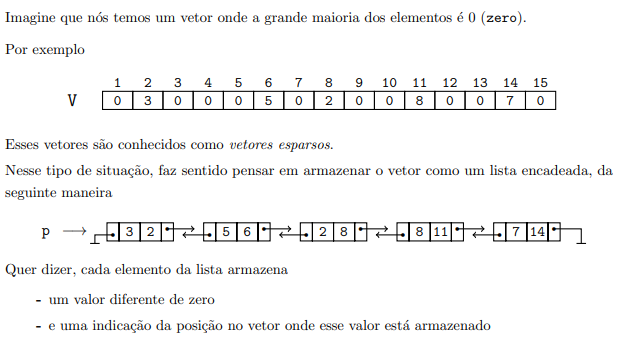

**a) Apresente um algoritmo que constrói a representação de um vetor esparso na forma de uma lista duplamente encadeada.**

In [6]:
import random

class NoEsparso:
    def __init__(self, valor_item, posicao):
        self.valor_item = valor_item
        self.posicao = posicao
        self.proximo = None
        self.anterior = None

def vetor_para_lista(item_vetor):
    limite_inferior = None
    limite_superior = None

    for indice in range(len(item_vetor)):
        if item_vetor[indice] != 0:
            novo_no = NoEsparso(item_vetor[indice], indice + 1)
            if limite_inferior is None:
                limite_inferior = novo_no
                limite_superior = novo_no
            else:
                limite_superior.proximo = novo_no
                novo_no.anterior = limite_superior
                limite_superior = novo_no

    return limite_inferior

def exibir_esparso(lista_ref):
    corrente = lista_ref
    valores_lista = []
    while corrente:
        valores_lista.append(f"[{corrente.valor_item}, pos:{corrente.posicao}]")
        corrente = corrente.proximo
    print("None <-> " + " <-> ".join(valores_lista) + " <-> None")

vetor = [0, 3, 0, 0, 0, 5, 0, 2, 0, 0, 8, 0, 0, 7, 0]
print("O vetor normal é:")
print(vetor)
resultado = vetor_para_lista(vetor)
print = ("\nA lista esparsa é:")
exibir_esparso(resultado)

O vetor normal é:
[0, 3, 0, 0, 0, 5, 0, 2, 0, 0, 8, 0, 0, 7, 0]
None <-> [3, pos:2] <-> [5, pos:6] <-> [2, pos:8] <-> [8, pos:11] <-> [7, pos:14] <-> None


**b) Analise o tempo de execução do seu algoritmo.**

O algoritmo possui tempo de execução O(N), linear, onde N é o número total de elementos do vetor original, pois percorre o vetor uma única vez de ponta a ponta e realiza inserções no final da lista encadeada em tempo constante O(1).

# 6. Operações sobre vetores esparsos.
___

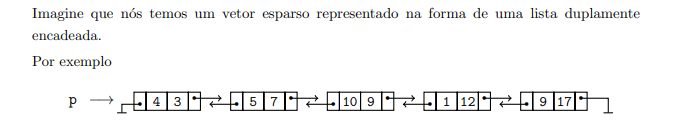

**a) Apresente algoritmos que implementam as seguintes operações sobre vetores esparsos**

- Busca-por-indice(k): retorna o valor armazenado na posição k

- Busca-por-valor (x): retorna a posição onde o valor x está armazenado (ou-1 se ele não está lá)

- Atualização (x,k): atualiza o valor da posição k para x

In [ ]:
def busca_indice(lista_ref, pivo):
    no_atual = lista_ref
    while no_atual is not None:
        if no_atual.posicao == pivo:
            return no_atual.valor_item
        no_atual = no_atual.proximo
    return 0

def busca_valor(lista_ref, valor_busca):
    no_atual = lista_ref
    while no_atual is not None:
        if no_atual.valor_item == valor_busca:
            return no_atual.posicao
        no_atual = no_atual.proximo
    return -1

def atualizacao(lista_ref, valor_busca, pivo):
    no_atual = lista_ref
    while no_atual is not None and no_atual.posicao < pivo:
        no_atual = no_atual.proximo

    if no_atual is None or no_atual.posicao > pivo:
        if valor_busca != 0:
            novo_no = NoEsparso(valor_busca, pivo)
            if no_atual is None:
                anterior_no = lista_ref
                while anterior_no is not None and anterior_no.proximo is not None:
                    anterior_no = anterior_no.proximo
                if anterior_no is not None:
                    anterior_no.proximo = novo_no
                    novo_no.anterior = anterior_no
                else:
                    lista_ref = novo_no
            else:
                anterior_no = no_atual.anterior
                novo_no.proximo = no_atual
                novo_no.anterior = anterior_no
                no_atual.anterior = novo_no
                if anterior_no is not None:
                    anterior_no.proximo = novo_no
                else:
                    lista_ref = novo_no
    else:
        if valor_busca == 0:
            anterior_no = no_atual.anterior
            proximo_no = no_atual.proximo
            if anterior_no is not None:
                anterior_no.proximo = proximo_no
            else:
                lista_ref = proximo_no
            if proximo_no is not None:
                proximo_no.anterior = anterior_no
        else:
            no_atual.valor_item = valor_busca

    return lista_ref

lista_ref = vetor_para_lista([0, 0, 4, 0, 5, 0, 0, 0, 10, 0, 0, 1, 0, 0, 0, 0, 9])
exibir_esparso(lista_ref)

valor_indice = busca_indice(lista_ref, 5)
print(valor_indice)

posicao_valor = busca_valor(lista_ref, 10)
print(posicao_valor)

lista_ref = atualizacao(lista_ref, 8, 3)
exibir_esparso(lista_ref)

None <-> [4, pos:3] <-> [5, pos:5] <-> [10, pos:9] <-> [1, pos:12] <-> [9, pos:17] <-> None
5
9
None <-> [8, pos:3] <-> [5, pos:5] <-> [10, pos:9] <-> [1, pos:12] <-> [9, pos:17] <-> None


**b) Analise o tempo de execução do seu algoritmo.**

As três operações (busca, insercao e remocao) possuem tempo de execução O(k + n/k), onde k é a quantidade de sublistas na lista de listas e n/k é o tamanho médio de cada sublista. Primeiro, faz-se a busca no vetor de ponteiros L percorrendo até k posições para encontrar a sublista correta; em seguida, percorre-se no máximo a sublista encontrada com tamanho médio n/k realizando verificações e ajustes de ponteiros em tempo constante O(1).

# 7. Lista de listas
___

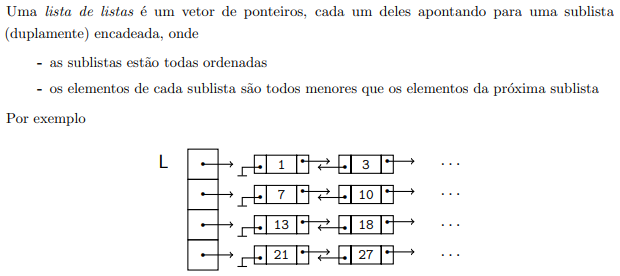

**a) Apresente um algoritmo que transforma uma lista duplamente encadeada em uma lista de
listas de tamanho k — (onde todas as sublistas tem (aproximadamente) o mesmo tamanho)**

In [ ]:
import math
import random

class No:
    def __init__(self, dado):
        self.dado = dado
        self.proximo = None
        self.anterior = None

def criar_lista_dupla(t, limite_inferior, limite_superior):
    if t <= 0:
        return None
    inicio_lista = No(random.randint(limite_inferior, limite_superior))
    corrente = inicio_lista
    for _ in range(t - 1):
        novo_no = No(random.randint(limite_inferior, limite_superior))
        corrente.proximo = novo_no
        novo_no.anterior = corrente
        corrente = novo_no
    return inicio_lista

def ordenar_dupla(lista_ref):
    if lista_ref is None:
        return None

    houve_troca = True
    while houve_troca:
        houve_troca = False
        no_atual = lista_ref
        while no_atual.proximo is not None:
            if no_atual.dado > no_atual.proximo.dado:
                no_atual.dado, no_atual.proximo.dado = no_atual.proximo.dado, no_atual.dado
                houve_troca = True
            no_atual = no_atual.proximo
    return lista_ref

def criar_lista_listas(lista_ref, pivo):
    if lista_ref is None or pivo <= 0:
        return []

    tot = 0
    no_atual = lista_ref
    while no_atual is not None:
        tot += 1
        no_atual = no_atual.proximo

    tam = math.ceil(tot / pivo)
    listas_sub = []

    corrente = lista_ref
    for indice in range(pivo):
        if corrente is None:
            listas_sub.append(None)
            continue

        listas_sub.append(corrente)

        for _ in range(tam - 1):
            if corrente.proximo is None:
                break
            corrente = corrente.proximo

        prox_sub = corrente.proximo
        corrente.proximo = None
        if prox_sub is not None:
            prox_sub.anterior = None

        corrente = prox_sub

    return listas_sub

def exibir_lista_listas(listas_sub):
    print("\nEstrutura Atual da Lista de Listas")
    for idx, sublista in enumerate(listas_sub):
        valores_lista = []
        corrente_sublista = sublista
        while corrente_sublista:
            valores_lista.append(str(corrente_sublista.dado))
            corrente_sublista = corrente_sublista.proximo
        print(f"Sublista {idx}: " + (" <-> ".join(valores_lista) if valores_lista else "Vazia"))

def busca(listas_sub, valor_busca):
    if not listas_sub:
        return False

    indice_sublista = -1
    for indice in range(len(listas_sub)):
        if listas_sub[indice] is not None and listas_sub[indice].dado <= valor_busca:
            indice_sublista = indice
        else:
            break

    if indice_sublista == -1:
        indice_sublista = 0

    no_atual = listas_sub[indice_sublista]
    while no_atual is not None:
        if no_atual.dado == valor_busca:
            return True
        if no_atual.dado > valor_busca:
            break
        no_atual = no_atual.proximo

    return False

def insercao(listas_sub, valor_busca):
    if not listas_sub:
        listas_sub.append(No(valor_busca))
        return listas_sub

    indice_sublista = -1
    for indice in range(len(listas_sub)):
        if listas_sub[indice] is not None and listas_sub[indice].dado <= valor_busca:
            indice_sublista = indice
        else:
            break

    if indice_sublista == -1:
        indice_sublista = 0

    novo_no = No(valor_busca)
    sublista = listas_sub[indice_sublista]

    if sublista is None:
        listas_sub[indice_sublista] = novo_no
        return listas_sub

    if valor_busca < sublista.dado:
        novo_no.proximo = sublista
        sublista.anterior = novo_no
        listas_sub[indice_sublista] = novo_no
        return listas_sub

    no_atual = sublista
    while no_atual.proximo is not None and no_atual.proximo.dado < valor_busca:
        no_atual = no_atual.proximo

    novo_no.proximo = no_atual.proximo
    novo_no.anterior = no_atual
    if no_atual.proximo is not None:
        no_atual.proximo.anterior = novo_no
    no_atual.proximo = novo_no

    return listas_sub

def remocao(listas_sub, valor_busca):
    if not listas_sub:
        return listas_sub

    indice_sublista = -1
    for indice in range(len(listas_sub)):
        if listas_sub[indice] is not None and listas_sub[indice].dado <= valor_busca:
            indice_sublista = indice
        else:
            break

    if indice_sublista == -1:
        indice_sublista = 0

    no_atual = listas_sub[indice_sublista]
    while no_atual is not None and no_atual.dado != valor_busca:
        no_atual = no_atual.proximo

    if no_atual is None:
        return listas_sub

    if no_atual.anterior is not None:
        no_atual.anterior.proximo = no_atual.proximo
    else:
        listas_sub[indice_sublista] = no_atual.proximo

    if no_atual.proximo is not None:
        no_atual.proximo.anterior = no_atual.anterior

    return listas_sub

lista_dupla = criar_lista_dupla(10, 1, 100)
lista_dupla = ordenar_dupla(lista_dupla)
listas_sub = criar_lista_listas(lista_dupla, 3)

exibir_lista_listas(listas_sub)

valor_teste = 15

print(f"\nInserindo o elemento {valor_teste}")
listas_sub = insercao(listas_sub, valor_teste)
exibir_lista_listas(listas_sub)

foi_encontrado = busca(listas_sub, valor_teste)
print(f"O elemento {valor_teste} foi encontrado na lista? {foi_encontrado}")

print(f"\nRemovendo o elemento {valor_teste}")
listas_sub = remocao(listas_sub, valor_teste)
exibir_lista_listas(listas_sub)

foi_encontrado = busca(listas_sub, valor_teste)
print(f"O elemento {valor_teste} foi encontrado na lista após remoção? {foi_encontrado}")


Estrutura Atual da Lista de Listas
Sublista 0: 12 <-> 24 <-> 24 <-> 27
Sublista 1: 30 <-> 49 <-> 58 <-> 62
Sublista 2: 72 <-> 80

Inserindo o elemento 15

Estrutura Atual da Lista de Listas
Sublista 0: 12 <-> 15 <-> 24 <-> 24 <-> 27
Sublista 1: 30 <-> 49 <-> 58 <-> 62
Sublista 2: 72 <-> 80
O elemento 15 foi encontrado na lista? True

Removendo o elemento 15

Estrutura Atual da Lista de Listas
Sublista 0: 12 <-> 24 <-> 24 <-> 27
Sublista 1: 30 <-> 49 <-> 58 <-> 62
Sublista 2: 72 <-> 80
O elemento 15 foi encontrado na lista após remoção? False


**b) Analise o tempo de execução do seu algoritmo.**

O algoritmo possui tempo de execução O(N), linear, onde N é o número total de nós da lista encadeada original, pois realiza uma contagem de n passos para determinar o tamanho total e, em seguida, percorre os N nós uma única vez ajustando as referências dos ponteiros em tempo constante O(1) para efetuar os cortes entre as sublistas.

# 8. Operações em lista de listas.
___

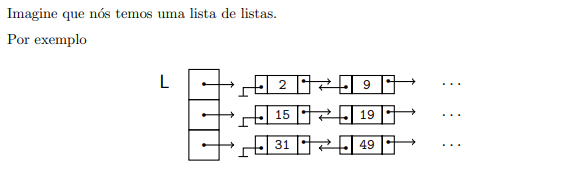

**a) Apresente algoritmos que implementam as seguintes operações sobre a lista de listas:**

• Busca(L,x)

• Inserção(L,x)

• Remoção(L,x)

In [5]:
def busca(listas_sub, valor_busca):
    if not listas_sub:
        return False

    indice_sublista = -1
    for indice in range(len(listas_sub)):
        if listas_sub[indice] is not None and listas_sub[indice].dado <= valor_busca:
            indice_sublista = indice
        else:
            break

    if indice_sublista == -1:
        indice_sublista = 0

    no_atual = listas_sub[indice_sublista]
    while no_atual is not None:
        if no_atual.dado == valor_busca:
            return True
        if no_atual.dado > valor_busca:
            break
        no_atual = no_atual.proximo

    return False

def insercao(listas_sub, valor_busca):
    if not listas_sub:
        listas_sub.append(No(valor_busca))
        return listas_sub

    indice_sublista = -1
    for indice in range(len(listas_sub)):
        if listas_sub[indice] is not None and listas_sub[indice].dado <= valor_busca:
            indice_sublista = indice
        else:
            break

    if indice_sublista == -1:
        indice_sublista = 0

    novo_no = No(valor_busca)
    sublista = listas_sub[indice_sublista]

    if sublista is None:
        listas_sub[indice_sublista] = novo_no
        return listas_sub

    if valor_busca < sublista.dado:
        novo_no.proximo = sublista
        sublista.anterior = novo_no
        listas_sub[indice_sublista] = novo_no
        return listas_sub

    no_atual = sublista
    while no_atual.proximo is not None and no_atual.proximo.dado < valor_busca:
        no_atual = no_atual.proximo

    novo_no.proximo = no_atual.proximo
    novo_no.anterior = no_atual
    if no_atual.proximo is not None:
        no_atual.proximo.anterior = novo_no
    no_atual.proximo = novo_no

    return listas_sub

def remocao(listas_sub, valor_busca):
    if not listas_sub:
        return listas_sub

    indice_sublista = -1
    for indice in range(len(listas_sub)):
        if listas_sub[indice] is not None and listas_sub[indice].dado <= valor_busca:
            indice_sublista = indice
        else:
            break

    if indice_sublista == -1:
        indice_sublista = 0

    no_atual = listas_sub[indice_sublista]
    while no_atual is not None and no_atual.dado != valor_busca:
        no_atual = no_atual.proximo

    if no_atual is None:
        return listas_sub

    if no_atual.anterior is not None:
        no_atual.anterior.proximo = no_atual.proximo
    else:
        listas_sub[indice_sublista] = no_atual.proximo

    if no_atual.proximo is not None:
        no_atual.proximo.anterior = no_atual.anterior

    return listas_sub

lista_dupla = criar_lista_dupla(10, 1, 100)
lista_dupla = ordenar_dupla(lista_dupla)
listas_sub = criar_lista_listas(lista_dupla, 3)

exibir_lista_listas(listas_sub)

valor_teste = 15

print(f"\nInserindo o elemento {valor_teste}")
listas_sub = insercao(listas_sub, valor_teste)
exibir_lista_listas(listas_sub)

foi_encontrado = busca(listas_sub, valor_teste)
print(f"O elemento {valor_teste} foi encontrado na lista? {foi_encontrado}")

print(f"\nRemovendo o elemento {valor_teste}")
listas_sub = remocao(listas_sub, valor_teste)
exibir_lista_listas(listas_sub)


Estrutura Atual da Lista de Listas
Sublista 0: 3 <-> 17 <-> 33 <-> 36
Sublista 1: 43 <-> 53 <-> 68 <-> 70
Sublista 2: 98 <-> 100

Inserindo o elemento 15

Estrutura Atual da Lista de Listas
Sublista 0: 3 <-> 15 <-> 17 <-> 33 <-> 36
Sublista 1: 43 <-> 53 <-> 68 <-> 70
Sublista 2: 98 <-> 100
O elemento 15 foi encontrado na lista? True

Removendo o elemento 15

Estrutura Atual da Lista de Listas
Sublista 0: 3 <-> 17 <-> 33 <-> 36
Sublista 1: 43 <-> 53 <-> 68 <-> 70
Sublista 2: 98 <-> 100


**b) Analise o tempo de execução do seu algoritmo.**

As três operações (busca, insercao e remocao) possuem tempo de execução O(k + N/k), onde k é a quantidade de sublistas na lista de listas e N/k é o tamanho médio de cada sublista. Primeiro, faz-se a busca no vetor de ponteiros L percorrendo até k posições para encontrar a sublista correta; em seguida, percorre-se no máximo a sublista encontrada com tamanho médio N/k realizando verificações e ajustes de ponteiros em tempo constante O(1).